In [188]:
import json
import random
import csv
import re
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [365]:
all_data = json.load(open('./raw_data.json', 'r'))
print(len(all_data))
for row in all_data:
    for item in row['items']:
        del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()

f = open('./raw_data_affnet_v2.json','w')
f.write(json.dumps(all_data))
f.close()

372


In [366]:
all_data = json.load(open('./raw_data_affnet_v2.json', 'r'))

In [367]:
len(all_data)

372

In [368]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_d=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 347
Data: 6940
Workers: 282


In [369]:
data[0]

{'file': 'affectnetsample/train_class/class008/image0029297.jpg',
 'paramoji': {'selection': 7,
  'iteration': 2,
  'value': [0.8829, 0.7402, 0.2923, 0.7569, 0.5024]},
 'startTime': 1646156307670,
 'endTime': 1646156330960,
 'worker': 'e5a83423',
 'paramoji_v': 0.8829,
 'paramoji_a1': 0.7402,
 'paramoji_a2': 0.2923,
 'paramoji_d': 0.7569,
 'paramoji_c': 0.5024}

In [370]:
iters = np.array([row['paramoji']['iteration'] for row in data])
print(np.mean(iters > 1.0))

0.19870317002881843


In [371]:
classes = ["Normal", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Anger", "Contempt"]
print(", ".join(classes))

Normal, Happy, Sad, Surprise, Fear, Disgust, Anger, Contempt


In [372]:
for item in data:
    c = int(re.search(r'class([0-9]+)', item['file']).group(1))
    #if c==6 and item['paramoji_c']> 0.1:
    #    c=8
    item['class'] = c
    item['name'] = classes[c-1]

In [373]:
df = pd.DataFrame(data)
g = df.groupby('class')
result = g.median()\
    .reset_index()\
    .drop(['startTime','endTime'], axis=1)\
    .sort_values(by='class')
result['name'] = np.array(classes)[[r-1 for r in result['class'].tolist()]]
result['count'] = g['class'].count().tolist()
result

,class,paramoji_v,paramoji_a1,paramoji_a2,paramoji_d,paramoji_c,name,count
0,1,0.57890,0.54120,0.15920,0.46025,0.0000,Normal,890
1,2,0.77530,0.50060,0.35740,0.48600,0.0494,Happy,671
2,3,0.42350,0.51480,0.15520,0.38010,0.0000,Sad,1049
3,4,0.62530,0.64885,0.46700,0.36760,0.0000,Surprise,852
4,5,0.43995,0.67780,0.50175,0.40015,0.0000,Fear,978
5,6,0.40840,0.50790,0.39310,0.58200,0.2092,Disgust,919
6,7,0.48340,0.56645,0.23925,0.51570,0.0000,Anger,740
7,8,0.70060,0.55040,0.20380,0.52120,0.1075,Contempt,841


In [374]:
result2 = result.copy(True)
for k in ['v', 'a1', 'a2', 'd', 'c']:
    key = "paramoji_"+k
    center = np.mean(result[key])
    result2[key] = np.maximum(0.0, np.minimum(1.0, (4*result[key]- 3*center).tolist()))

In [375]:
result2

,class,paramoji_v,paramoji_a1,paramoji_a2,paramoji_d,paramoji_c,name,count
0,1,0.652344,0.4743,0.000000,0.448625,0.000000,Normal,890
1,2,1.000000,0.3119,0.500837,0.551625,0.060312,Happy,671
2,3,0.030744,0.3687,0.000000,0.128025,0.000000,Sad,1049
3,4,0.837944,0.9049,0.939238,0.078025,0.000000,Surprise,852
4,5,0.096544,1.0000,1.000000,0.208225,0.000000,Fear,978
5,6,0.000000,0.3411,0.643637,0.935625,0.699512,Disgust,919
6,7,0.270344,0.5753,0.028238,0.670425,0.000000,Anger,740
7,8,1.000000,0.5111,0.000000,0.692425,0.292712,Contempt,841


In [376]:
f = open('gen/affnet/results.json','w')
f.write(result2.to_json(orient='records'))
f.close()

In [377]:
for off in [0,4]:
    rows = [result.iloc[off + i] for i in range(4)]
    print("\\raisebox{6ex}{$4x-3\\overline{x}$}")
    for row in rows:
        center = np.mean(result[key])
        paramoji= ",".join([
            f"{max(0, min(1, (4*row['paramoji_'+k]-3*np.mean(result['paramoji_'+k]))))*100:.0f}" 
            for k in ['v', 'a1', 'a2', 'd', 'c']])
        print(f"& \paramoji{{{paramoji}}}")
    print('\\\\')
    print("class ", end="")
    for row in rows:
        print(f"& {row['name']} ", end="")
    print('\\\\[1ex]')
    for k in ['v', 'a_1', 'a_2', 'd', 'c']:
        print("%8s" % f"${k}$ ", end="") 
        for row in rows:
            print(f"& {row['paramoji_'+k.replace('_','')]:.2f} ", end="")
        print('\\\\')
    print("      n ", end="") 
    for row in rows:
        print(f"& {row['count']:4d} ", end="")
    if off==0: print('\\\\')
    

\raisebox{6ex}{$4x-3\overline{x}$}
& \paramoji{65,47,0,45,0}
& \paramoji{100,31,50,55,6}
& \paramoji{3,37,0,13,0}
& \paramoji{84,90,94,8,0}
\\
class & Normal & Happy & Sad & Surprise \\[1ex]
    $v$ & 0.58 & 0.78 & 0.42 & 0.63 \\
  $a_1$ & 0.54 & 0.50 & 0.51 & 0.65 \\
  $a_2$ & 0.16 & 0.36 & 0.16 & 0.47 \\
    $d$ & 0.46 & 0.49 & 0.38 & 0.37 \\
    $c$ & 0.00 & 0.05 & 0.00 & 0.00 \\
      n &  890 &  671 & 1049 &  852 \\
\raisebox{6ex}{$4x-3\overline{x}$}
& \paramoji{10,100,100,21,0}
& \paramoji{0,34,64,94,70}
& \paramoji{27,58,3,67,0}
& \paramoji{100,51,0,69,29}
\\
class & Fear & Disgust & Anger & Contempt \\[1ex]
    $v$ & 0.44 & 0.41 & 0.48 & 0.70 \\
  $a_1$ & 0.68 & 0.51 & 0.57 & 0.55 \\
  $a_2$ & 0.50 & 0.39 & 0.24 & 0.20 \\
    $d$ & 0.40 & 0.58 & 0.52 & 0.52 \\
    $c$ & 0.00 & 0.21 & 0.00 & 0.11 \\
      n &  978 &  919 &  740 &  841 

In [43]:
"abc".replace("a","b")

'bbc'

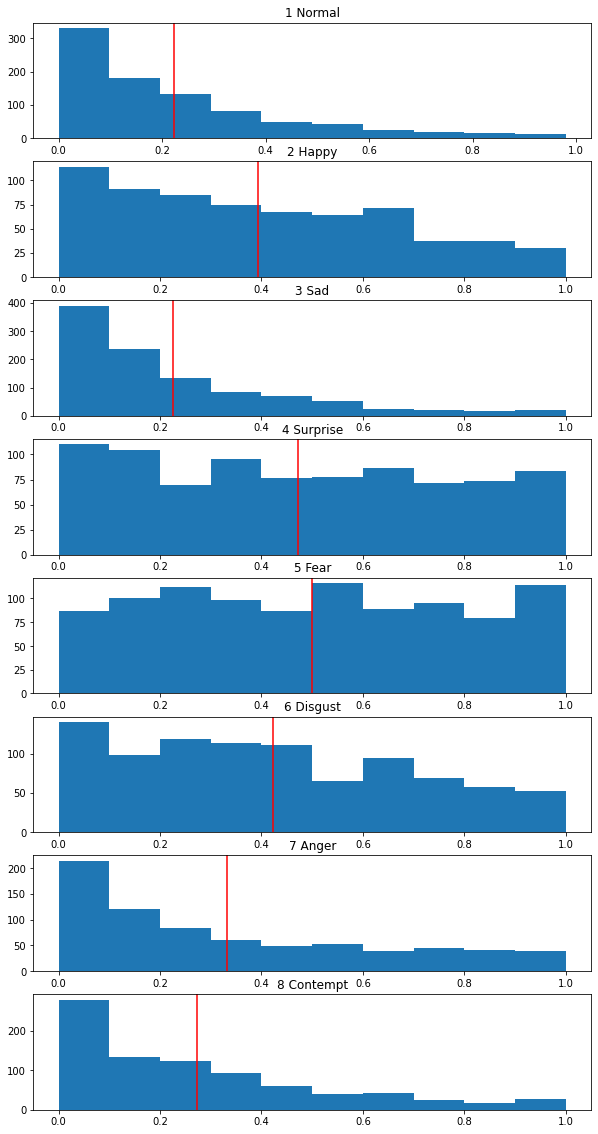

In [378]:
fig, ax = plt.subplots(8,1,figsize=(10,20))
for i in range(len(classes)):
    label = classes[i]
    sel = [row['paramoji_a2'] for row in data if row['name']==label]
    ax[i].hist(sel)
    ax[i].set_title(f"{i+1} {label}")
    x=np.mean(sel)
    ax[i].axvline(x, color='red')